# Figures for axisymmetrically forced planets (aka slow rotators) from Nicolas & Vallis (2026): Mechanisms of Superrotation in Slowly-Rotating and Tidally-Locked Planets

Use this notebook to reproduce figures 10-12 from the paper. The notebook requires output from two-level simulations of tidally locked planets.
See README.md for how to run these simulations.

In [1]:
import numpy as np
import xarray as xr
import os

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib.path as mpath
import cartopy.crs as ccrs

from emfcTools import get_emfc_spectra_nondim_zeta, cospec_kc_from_cospec
from processingTools import open_h5s_wgauge
from plottingTools import plot_map, filter_mode, add_ticks

%load_ext autoreload
%autoreload 2

In [2]:
# Adapt to your local setup
SNAPSHOTS_DIR = '/Users/qnicolas/superrotation/data/' 

# Loading & preparing simulation data

In [3]:
# Parameter grid
tau_rad_nondims = np.array([10,15,25,40,65,100,150,250,400,650,1000])
Ro_Ts  = tau_rad_nondims/100

In [4]:
# # Save simulation output to netcdf, quicker to open
# for Ro_T in Ro_Ts:
#     print(Ro_T)
#     for tau_rad_nondim in tau_rad_nondims:
#         print(tau_rad_nondim)
#         snapshot_id = 'snapshots_2levelnondim_T64_axi_%.2f_%.2f_%i_0p05'%(Ro_T,0.02,tau_rad_nondim)
#         snapshot_id = snapshot_id.replace('.','p')
#         outfile = SNAPSHOTS_DIR + "largesweep_tl/{}.nc".format(snapshot_id)
#         if os.path.isfile(outfile):
#             print(outfile + ' exists')
#         else:
#             snapshot = open_h5s_wgauge(snapshot_id,('s1','s2'),gauge_names=('tau',),SNAPSHOTS_DIR = SNAPSHOTS_DIR + 'largesweep_tl/')
#             snapshot.rename({'':'component'}).to_netcdf(outfile)

In [5]:
# Load simulation data
T64_2lev_axi={}
for Ro_T in Ro_Ts:
    for tau_rad_nondim in tau_rad_nondims:
        snapshot_id = 'snapshots_2levelnondim_T64_axi_%.2f_0p02_%i_0p05'%(Ro_T,tau_rad_nondim)
        snapshot_id = snapshot_id.replace('.','p')
        snapshot = xr.open_dataset(SNAPSHOTS_DIR+"largesweep_axi/%s.nc"%snapshot_id).sel(t=slice(300 * 4 * np.pi,None))
        T64_2lev_axi[Ro_T,tau_rad_nondim] = snapshot

[iacmac-ds4973:39624] shmem: mmap: an error occurred while determining whether or not /var/folders/g5/y1nh4h6x3j3c3lh5frsdkvtc0000gq/T//ompi.iacmac-ds4973.503/jf.0/976093184/sm_segment.iacmac-ds4973.503.3a2e0000.0 could be created.


# Regime diagram

In [6]:
equilibrated_Us = np.zeros((len(Ro_Ts),len(tau_rad_nondims)))
fraction_time_superrotating = np.zeros((len(Ro_Ts),len(tau_rad_nondims)))
for i,Ro_T in enumerate(Ro_Ts):
    print(Ro_T)
    for j,tau_rad_nondim in enumerate(tau_rad_nondims):
        print(tau_rad_nondim,end=' ')
        sim = T64_2lev_axi[Ro_T,tau_rad_nondim]

        # Average zonal wind in 2°S-2°N, time average over 300-1000 days
        u_ts = sim.u1[:,0].sel(latitude=slice(-2,2)).mean(('latitude','longitude'))
        equilibrated_Us[i,j] = float(u_ts.mean('t').data)
        fraction_time_superrotating[i,j] = (u_ts>0).mean()

    print('')

equilibrated_Us_xr = xr.DataArray(equilibrated_Us,coords={'Ro_T':np.array(Ro_Ts),'tau_rad_nondim':np.array(tau_rad_nondims)},dims=['Ro_T','tau_rad_nondim'])
unstable = (fraction_time_superrotating > 0.1) * (fraction_time_superrotating < 0.9)
unstable_xr = xr.DataArray(unstable, coords=equilibrated_Us_xr.coords, dims=equilibrated_Us_xr.dims)


0.1
10 15 25 40 65 100 150 250 400 650 1000 
0.15
10 15 25 40 65 100 150 250 400 650 1000 
0.25
10 15 25 40 65 100 150 250 400 650 1000 
0.4
10 15 25 40 65 100 150 250 400 650 1000 
0.65
10 15 25 40 65 100 150 250 400 650 1000 
1.0
10 15 25 40 65 100 150 250 400 650 1000 
1.5
10 15 25 40 65 100 150 250 400 650 1000 
2.5
10 15 25 40 65 100 150 250 400 650 1000 
4.0
10 15 25 40 65 100 150 250 400 650 1000 
6.5
10 15 25 40 65 100 150 250 400 650 1000 
10.0
10 15 25 40 65 100 150 250 400 650 1000 


In [7]:
# Earth
Omega = 2*np.pi / 86400
a = 6.378e6  # m
DeltaTheta = 60
cp = 1004.
taurad = 40 * 86400

Ro_T = cp * DeltaTheta / (2 * Omega * a)**2
tau_rad_nondim = 2 * Omega * taurad

print("RoT = %.3f"%Ro_T,
      "Trad = %.2f"%tau_rad_nondim)

Earth = {'Ro_T':Ro_T,'tau_rad_nondim':tau_rad_nondim}

RoT = 0.070 Trad = 502.65


In [8]:
# Mars
Omega = 2*np.pi / 86400 / 1.027
a = 6.378e6 * 0.532 # m
DeltaTheta = 100 # from Haberle et al 1997 JGR
cp = 7.3594e2 # from Nasa Mars GCM github
taurad = 2 * 86400 # from Haberle et al 1997 JGR

Ro_T = cp * DeltaTheta / (2 * Omega * a)**2
tau_rad_nondim = 2 * Omega * taurad

print("RoT = %.3f"%Ro_T,
      "Trad = %.2f"%tau_rad_nondim)

Mars = {'Ro_T':Ro_T,'tau_rad_nondim':tau_rad_nondim}

RoT = 0.319 Trad = 24.47


In [9]:
# Titan (mitchell and Lora 2016)
Omega = 2*np.pi / (15.94 * 86400) 
a = 2575e3
DeltaTheta = 20
cp = 1e3
taurad = 10**(8.5) # Bézard et al 2017

Ro_T = cp * DeltaTheta / (2 * Omega * a)**2
tau_rad_nondim = 2 * Omega * taurad

print("RoT = %.3f"%Ro_T,
      "Trad = %.2f"%tau_rad_nondim)

Titan = {'Ro_T':Ro_T,'tau_rad_nondim':tau_rad_nondim}

RoT = 36.229 Trad = 2885.41


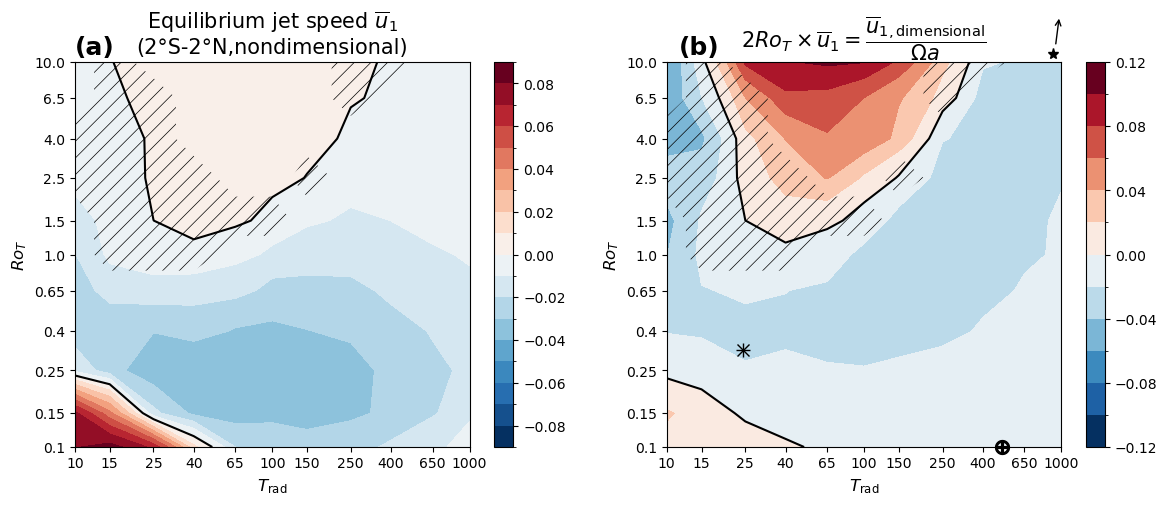

In [10]:
matplotlib.rcParams['hatch.linewidth'] = 0.5
matplotlib.rcParams['font.size'] = 10
fig,axs=plt.subplots(1,2,figsize=(14,5))

# Plot with two nondimensionalizations
for ax,us,levs in zip(axs,
                      [equilibrated_Us_xr, equilibrated_Us_xr * equilibrated_Us_xr.Ro_T * 2],
                      [np.arange(-0.09,0.091,0.01),np.arange(-0.3,0.31,0.05)/5*2]
                      ):
    us.plot.contourf(ax=ax,levels = levs)
    unstable_xr.plot.contourf(ax=ax, levels=[0.5,1], colors='none', hatches=['','//'], alpha=0,add_colorbar=False)
    us.plot.contour(ax=ax, levels=[0.], colors=['k'])
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_yticks(Ro_Ts)
    ax.set_xticks(tau_rad_nondims)
    ax.set_yticklabels(Ro_Ts)
    ax.set_xticklabels(tau_rad_nondims)
    ax.set_xlabel(r"$T_\mathrm{rad}$",fontsize=12)
    ax.set_ylabel(r"$Ro_T$",fontsize=12)
    ax.minorticks_off()


# Planets
# Earth - clip Ro_T to 0.1 for better visibility
ax.plot(Earth['tau_rad_nondim'],0.1,marker=r'$\oplus$',markersize=10,color='k',zorder=10,clip_on=False)

# Mars
ax.plot(Mars['tau_rad_nondim'],Mars['Ro_T'],marker='+',markersize=10,color='k',zorder=10)
ax.plot(Mars['tau_rad_nondim'],Mars['Ro_T'],marker='x',markersize=8,color='k',zorder=10)

# Titan
star = mpath.Path.unit_regular_star(6)
ax.plot(.98,1.02,marker='*',markersize=8,color='k',zorder=10,transform = ax.transAxes, clip_on = False)
x0 = 0.985; y0 = 1.04
ax.annotate("", xy=(x0,y0), xytext=(x0+0.01,y0+0.08),arrowprops=dict(arrowstyle="<-"), xycoords='axes fraction')


axs[0].text(0.,1.02,"(a)",fontweight='bold',fontsize=18,transform = axs[0].transAxes)
axs[1].text(0.03,1.02,"(b)",fontweight='bold',fontsize=18,transform = axs[1].transAxes)

axs[0].set_title(r"Equilibrium jet speed $\overline{u}_1$"+"\n(2°S-2°N,nondimensional)",fontsize=15)
axs[1].set_title(r"$2Ro_T \times \overline{u}_1 = \dfrac{\overline{u}_{1,\mathrm{dimensional}}}{\Omega a}$",fontsize=15)

fig.savefig('figs/regime_diagram_axi.pdf',format='pdf',bbox_inches='tight')

# RK mode figure for $Ro_T = 10$, $T_{rad} = 25$

In [11]:
def prep_sim(sim,Ro_T,phase_speeds = np.linspace(-1.,1.,2001)):
    sim['u1_tmean']     = sim.u1.mean('t')
    sim['u1x_tmean']    = sim['u1_tmean'].mean('longitude')[0]

    cospec = get_emfc_spectra_nondim_zeta(sim,Ro_T)
    sim['cospec'] = cospec
    cospec_transients = cospec * (cospec.frequency !=0)
    cospec_kc = cospec_kc_from_cospec(cospec_transients,phase_speeds = phase_speeds)
    sim['cospec_transients_kc'] = cospec_kc

def plot_mode(ax,sim,k,freq,levs=None,ticks=None):
    u = filter_mode( sim.u1[:,0],k,freq).transpose('longitude','latitude')
    minusv = filter_mode( sim.u1[:,1],k,freq).transpose('longitude','latitude')
    u_vector = xr.concat([u,minusv],dim='component')
    phi = filter_mode(sim.Phi1,k,freq)

    plot_map(ax, phi, u_vector,
             levels=levs, cmap = 'RdBu_r', wind_disc=2, 
             cbar_kwargs={'label':r'$\Phi_1$','pad':0.02,'ticks':ticks})
    
    add_ticks(ax,lons=[-180,0,180],lats=[-45,0,45],sz=14)
    

In [12]:
Ro_T = 10.
tau_rad_nondim = 25
sim = T64_2lev_axi[Ro_T,tau_rad_nondim]

prep_sim(sim, Ro_T)

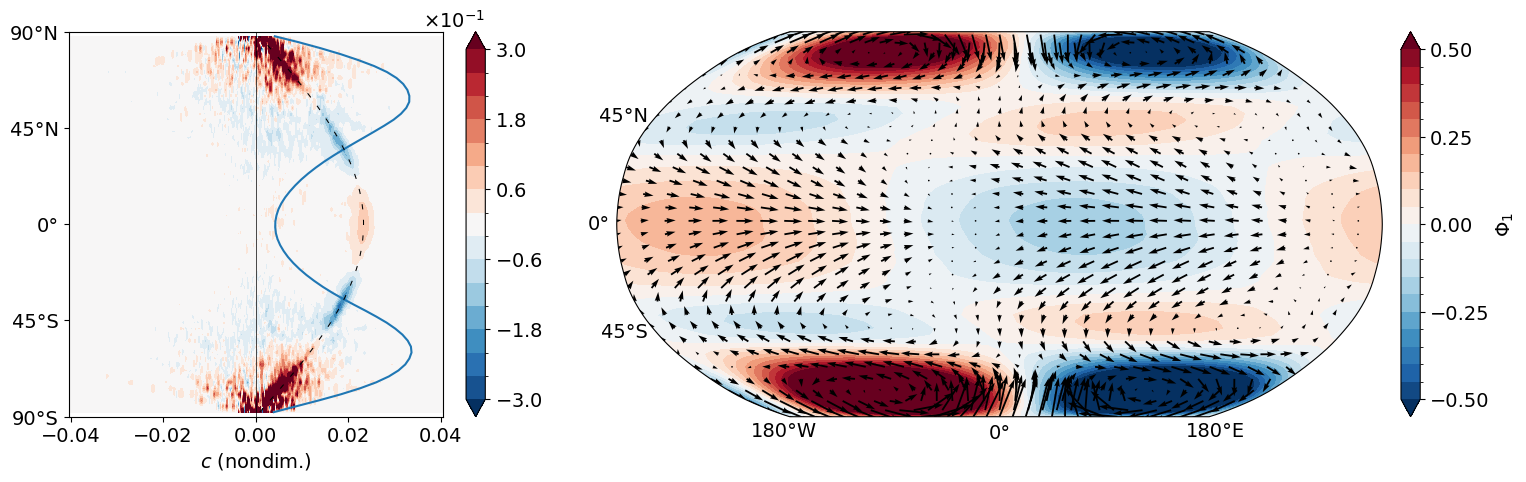

In [13]:
matplotlib.rcParams['font.size'] = 14
fig = plt.figure(figsize=(19,5))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 2],wspace=0.1) 


####### First plot : EMFC cospectrum ######
ax = plt.subplot(gs[0])
cospec_kc = sim['cospec_transients_kc']
# Change to velocity-based nondimensionalization for c, as opposed to frequency-based
cospec_kc = cospec_kc.assign_coords(c = cospec_kc.c / Ro_T) * Ro_T

MM = 0.3
dM = 0.04 
cf = cospec_kc.sum(('kphi')).plot.contourf(ax=ax,y='latitude',levels = np.arange(-MM,MM+1e-6,dM),extend='both',add_colorbar=False)
cbar = fig.colorbar(cf,ax=ax,label='',ticks = np.arange(-MM,MM+1e-6,3*dM))
cbar.formatter.set_powerlimits((0, 0))
cbar.formatter.set_useMathText(True)

# Plot critical line
(sim.u1x_tmean).plot(ax=ax,y='latitude')

# Plot line of constant frequency corresponding to EMFC maximum at the equator
k=1 # wavenumber 
freq = sim.frequency[(sim.cospec * (sim.cospec.frequency != 0)).sel(latitude=slice(-10,10)).mean('latitude').sel(kphi=k).argmax()]
(np.sin(sim.theta) * freq / Ro_T ).plot(ax=ax,y='latitude',color='k',linewidth=0.75,linestyle='--',dashes=(5, 10))


# Axis cosmetics
M = np.abs(sim.u1x_tmean).max()
ax.set_xlim(-1.2*M,1.2*M)
ax.axvline(0.,color='k',lw=.5,ls='-')
ax.set_title('')
ax.set_xlabel(r'$c$ (nondim.)')
ax.set_ylabel('')
ax.set_yticks(range(-90,91,45))
ax.set_yticklabels(['90°S','45°S','0°','45°N','90°N'])

####### Second plot : RK mode structure ######
ax = plt.subplot(gs[1],projection = ccrs.Robinson())
plot_mode(ax,sim,k,freq,levs=np.linspace(-1,1,21)/2,ticks=np.arange(-1.,1.01,0.5)/2)
ax.set_title('')

fig.savefig('figs/RK_axi.pdf',format='pdf',bbox_inches='tight')


# RK diagnostics

In [14]:
def prep_sim(sim):
    sim['u1x_tmean']     = sim.u1.sel(t=slice(600*np.pi,None)).mean(('t','longitude'))[0]
    sim['u2x_tmean']     = sim.u2.sel(t=slice(600*np.pi,None)).mean(('t','longitude'))[0]
    sim['S'] = (sim.theta1 - sim.theta2).sel(t=slice(600*np.pi,None),latitude=slice(-20,20)).mean()

for Ro_T in Ro_Ts:
    print(Ro_T,end=' ')
    for tau_rad_nondim in tau_rad_nondims:
        print(tau_rad_nondim,end=' ')
        sim = T64_2lev_axi[Ro_T,tau_rad_nondim]
        prep_sim(sim)
    print('')

0.1 10 15 25 40 65 100 150 250 400 650 1000 
0.15 10 15 25 40 65 100 150 250 400 650 1000 
0.25 10 15 25 40 65 100 150 250 400 650 1000 
0.4 10 15 25 40 65 100 150 250 400 650 1000 
0.65 10 15 25 40 65 100 150 250 400 650 1000 
1.0 10 15 25 40 65 100 150 250 400 650 1000 
1.5 10 15 25 40 65 100 150 250 400 650 1000 
2.5 10 15 25 40 65 100 150 250 400 650 1000 
4.0 10 15 25 40 65 100 150 250 400 650 1000 
6.5 10 15 25 40 65 100 150 250 400 650 1000 
10.0 10 15 25 40 65 100 150 250 400 650 1000 


In [15]:
# Calculate nondimensional numbers:
# Midlatitude Rossby number, measured at the latitude of maximum zonal wind
# Froude number
# And ratio of rossby deformation radius to latitude of midlatitude jets

# initialize arrays
Ros = np.zeros((len(Ro_Ts),len(tau_rad_nondims)))
Fr = np.zeros((len(Ro_Ts),len(tau_rad_nondims)))
Ld_ov_phi0 = np.zeros((len(Ro_Ts),len(tau_rad_nondims)))

for i,Ro_T in enumerate(Ro_Ts):
    for j,tau_rad_nondim in enumerate(tau_rad_nondims):
        sim = T64_2lev_axi[Ro_T,tau_rad_nondim]

        # Average wind over depth and hemispheres
        u_mean = (sim['u1x_tmean']+sim['u2x_tmean'])/2
        u_mean = (u_mean + u_mean[::-1])/2

        # Maximum zonal wind and its latitude
        u_jet = u_mean.max('latitude')
        phi0 = np.abs(sim.latitude[u_mean.argmax('latitude')]) * np.pi / 180

        # Equatorial zonal wind
        u_eq = u_mean.sel(latitude=slice(-30,30)).mean('latitude')

        # Kelvin wave phase speed
        c = np.sqrt(0.12 * sim.S / (2 * Ro_T))

        Ros[i,j] =  Ro_T * u_jet
        Fr[i,j] = u_jet / np.cos(phi0) / ( u_eq + c )
        Ld_ov_phi0[i,j] = np.sqrt(Ro_T * c) / phi0

Ros_xr = xr.DataArray(Ros,coords={'Ro_T':np.array(Ro_Ts),'tau_rad_nondim':np.array(tau_rad_nondims)},dims=['Ro_T','tau_rad_nondim'])
Fr_xr = xr.DataArray(Fr,coords={'Ro_T':np.array(Ro_Ts),'tau_rad_nondim':np.array(tau_rad_nondims)},dims=['Ro_T','tau_rad_nondim'])
Ld_ov_phi0_xr = xr.DataArray(Ld_ov_phi0,coords={'Ro_T':np.array(Ro_Ts),'tau_rad_nondim':np.array(tau_rad_nondims)},dims=['Ro_T','tau_rad_nondim'])

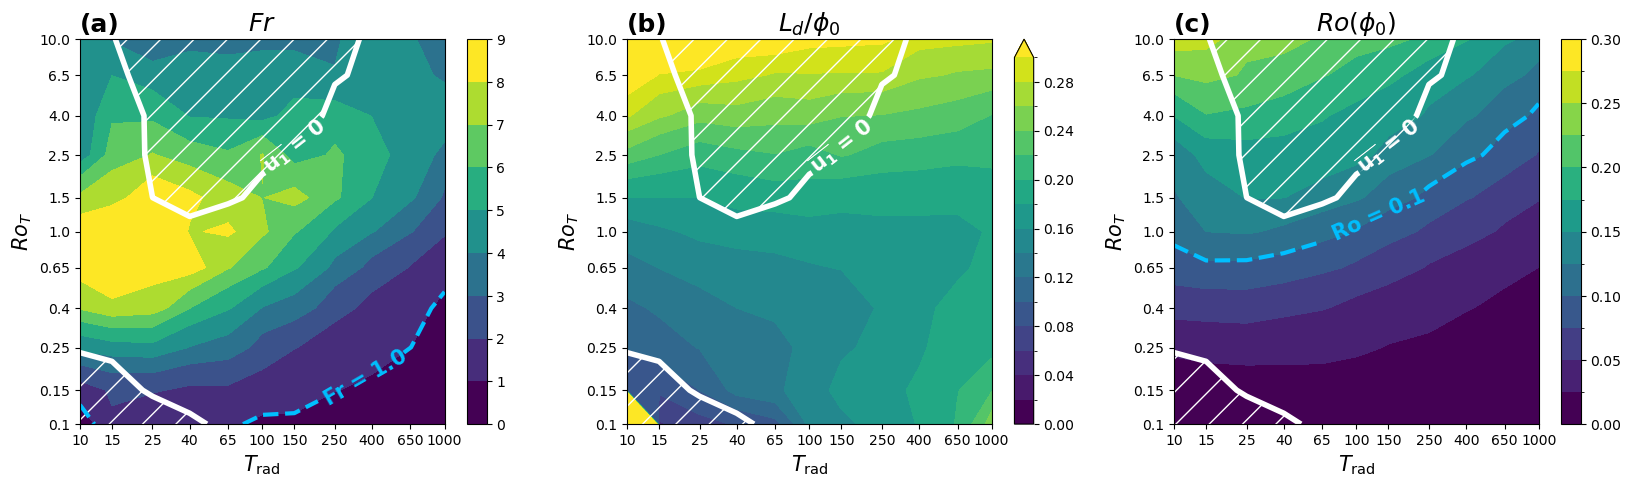

In [16]:
matplotlib.rcParams['hatch.color'] = 'w'
matplotlib.rcParams['hatch.linewidth'] = 1.
matplotlib.rcParams['font.size'] = 10

fig,axs=plt.subplots(1,3,figsize=(20,5))

###### Froude number plot #######
ax=axs[0]
Fr_xr.plot.contourf(ax=ax,levels=np.arange(0,9.1,1.))
c = Fr_xr.plot.contour(ax=ax,levels=[1.],colors='deepskyblue',linestyles='--',linewidths=[3.])

cl = ax.clabel(c, c.levels, fontsize=15,fmt = "   Fr = %.1f     ")
for l in cl:
    l.set_rotation(30)
    l.set_fontweight('bold')

###### Ld / phi0 plot #######
ax = axs[1]
Ld_ov_phi0_xr.plot.contourf(ax=ax,levels = np.arange(0,0.32,0.02))

###### Midlatitude Rossby number plot #######
ax=axs[2]
Ros_xr.plot.contourf(ax=ax,levels = np.arange(0,0.31,0.025))
c = Ros_xr.plot.contour(ax=ax,levels=[.1],colors='deepskyblue',linestyles='--',linewidths=[3.])

cl = ax.clabel(c, c.levels, fontsize=15,fmt = "Ro = %.1f   ",inline_spacing=-20)#, fmt=fmt,manual=[[40.,1,]])#,inline=True )
for l in cl:
    l.set_fontweight('bold')


# Axis cosmetics
for ax in axs:
    c = equilibrated_Us_xr.plot.contour(ax=ax,levels=[0.],colors='w',linestyles='-',linewidths=[4.])
    equilibrated_Us_xr.plot.contourf(ax=ax, levels=[0.,10.], colors='none', hatches=['','/'], alpha=0,add_colorbar=False)

    cl = ax.clabel(c, c.levels, fontsize=15,fmt = r"$\mathbf{\overline{u_1}}$ = %i   ",inline_spacing=0, manual=[[150.,3,]])#,inline=True )
    for l in cl:
        l.set_fontweight('bold')
        l.set_rotation(38)

    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_yticks(Ro_Ts)
    ax.set_xticks(tau_rad_nondims)
    ax.set_yticklabels(Ro_Ts)
    ax.set_xticklabels(tau_rad_nondims)
    ax.set_xlabel(r"$T_\mathrm{rad}$",fontsize=15)
    ax.set_ylabel(r"$Ro_T$",fontsize=15)
    ax.minorticks_off()

for ax, ttl in zip(axs, [r'$Fr$', r'$L_d / \phi_0$', r'$Ro(\phi_0)$']):
    ax.set_title(ttl,fontsize=18)
for ax, ttl in zip(axs, ['(a)', '(b)', '(c)']):
    ax.text(0.,1.02,ttl,fontweight='bold',fontsize=18,transform = ax.transAxes)
fig.savefig('figs/Fr_Ro.pdf',format='pdf',bbox_inches='tight')